In [1]:
import os  #Provides functions to interact with the operating system.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import plotly.express as px    #Easy-to-use Plotly interface for interactive charts like scatter plots, line graphs, etc.
import plotly.graph_objects

Matplotlib is building the font cache; this may take a moment.


In [2]:
bowls = pd.read_csv("https://raw.githubusercontent.com/Naman-Agrawal19/ipl_data_2008_2024/refs/heads/main/deliveries.csv")
matches = pd.read_csv("https://raw.githubusercontent.com/Naman-Agrawal19/ipl_data_2008_2024/refs/heads/main/matches.csv")

In [3]:
matches.shape

(1095, 20)

In [4]:
bowls.shape

(260920, 17)

In [5]:
df = bowls.merge(matches, left_on = "match_id", right_on = "id", how= "left")

In [6]:
print(df.shape)
df.T

(260920, 37)


,0,1,2,3,4,5,6,7,8,9,...,260910,260911,260912,260913,260914,260915,260916,260917,260918,260919
match_id,335982,335982,335982,335982,335982,335982,335982,335982,335982,335982,...,1426312,1426312,1426312,1426312,1426312,1426312,1426312,1426312,1426312,1426312
inning,1,1,1,1,1,1,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2
batting_team,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,...,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders
bowling_team,Royal Challengers Bangalore,Royal Challengers Bangalore,Royal Challengers Bangalore,Royal Challengers Bangalore,Royal Challengers Bangalore,Royal Challengers Bangalore,Royal Challengers Bangalore,Royal Challengers Bangalore,Royal Challengers Bangalore,Royal Challengers Bangalore,...,Sunrisers Hyderabad,Sunrisers Hyderabad,Sunrisers Hyderabad,Sunrisers Hyderabad,Sunrisers Hyderabad,Sunrisers Hyderabad,Sunrisers Hyderabad,Sunrisers Hyderabad,Sunrisers Hyderabad,Sunrisers Hyderabad
over,0,0,0,0,0,0,0,1,1,1,...,8,9,9,9,9,9,9,10,10,10
ball,1,2,3,4,5,6,7,1,2,3,...,6,1,2,3,4,5,6,1,2,3
batter,SC Ganguly,BB McCullum,BB McCullum,BB McCullum,BB McCullum,BB McCullum,BB McCullum,BB McCullum,BB McCullum,BB McCullum,...,SS Iyer,VR Iyer,VR Iyer,VR Iyer,VR Iyer,SS Iyer,VR Iyer,VR Iyer,SS Iyer,VR Iyer
bowler,P Kumar,P Kumar,P Kumar,P Kumar,P Kumar,P Kumar,P Kumar,Z Khan,Z Khan,Z Khan,...,Shahbaz Ahmed,AK Markram,AK Markram,AK Markram,AK Markram,AK Markram,AK Markram,Shahbaz Ahmed,Shahbaz Ahmed,Shahbaz Ahmed
non_striker,BB McCullum,SC Ganguly,SC Ganguly,SC Ganguly,SC Ganguly,SC Ganguly,SC Ganguly,SC Ganguly,SC Ganguly,SC Ganguly,...,VR Iyer,SS Iyer,SS Iyer,SS Iyer,SS Iyer,VR Iyer,SS Iyer,SS Iyer,VR Iyer,SS Iyer
batsman_runs,0,0,0,0,0,0,0,0,4,4,...,4,2,0,0,1,1,1,1,1,1


In [7]:
def null_percentage(df):
    total_rows = df.shape[0]  # Total number of rows
    null_counts = df.isnull().sum()  # Number of nulls per column
    null_percentages = (null_counts / total_rows) * 100  # Percentage of nulls
    null_percentages = null_percentages.round(1)  # Round to 1 decimal place

    print("Null percentage for all columns:\n", null_percentages)
    print("-" * 30)

    # Columns with null values
    columns_with_nulls = null_percentages[null_percentages > 0] # Corrected indentation
    print("Columns with nulls:", columns_with_nulls.index.tolist())
    print("Number of columns with nulls:", len(columns_with_nulls))
    print("-" * 30)
    columns_without_nulls = null_percentages[null_percentages == 0]
    print("Columns without nulls:", columns_without_nulls.index.tolist())
    print("Number of columns without nulls:", len(columns_without_nulls))
    print("-" * 30)

    # Return only columns that have nulls with % symbol
    return (columns_with_nulls.astype(str) + "%")

In [8]:
null_percentage(bowls)

Null percentage for all columns:
 match_id             0.0
inning               0.0
batting_team         0.0
bowling_team         0.0
over                 0.0
ball                 0.0
batter               0.0
bowler               0.0
non_striker          0.0
batsman_runs         0.0
extra_runs           0.0
total_runs           0.0
extras_type         94.6
is_wicket            0.0
player_dismissed    95.0
dismissal_kind      95.0
fielder             96.4
dtype: float64
------------------------------
Columns with nulls: ['extras_type', 'player_dismissed', 'dismissal_kind', 'fielder']
Number of columns with nulls: 4
------------------------------
Columns without nulls: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'is_wicket']
Number of columns without nulls: 13
------------------------------


extras_type         94.6%
player_dismissed    95.0%
dismissal_kind      95.0%
fielder             96.4%
dtype: object

In [9]:
null_percentage(matches)

Null percentage for all columns:
 id                  0.0
season              0.0
city                4.7
date                0.0
match_type          0.0
player_of_match     0.5
venue               0.0
team1               0.0
team2               0.0
toss_winner         0.0
toss_decision       0.0
winner              0.5
result              0.0
result_margin       1.7
target_runs         0.3
target_overs        0.3
super_over          0.0
method             98.1
umpire1             0.0
umpire2             0.0
dtype: float64
------------------------------
Columns with nulls: ['city', 'player_of_match', 'winner', 'result_margin', 'target_runs', 'target_overs', 'method']
Number of columns with nulls: 7
------------------------------
Columns without nulls: ['id', 'season', 'date', 'match_type', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'super_over', 'umpire1', 'umpire2']
Number of columns without nulls: 13
------------------------------


city                4.7%
player_of_match     0.5%
winner              0.5%
result_margin       1.7%
target_runs         0.3%
target_overs        0.3%
method             98.1%
dtype: object

In [10]:
# Access the correct column and get its shape
df['method'].shape

(260920,)

In [11]:
df['winner'].value_counts()


winner
Mumbai Indians                 34629
Chennai Super Kings            33388
Kolkata Knight Riders          30820
Royal Challengers Bangalore    27319
Rajasthan Royals               27029
Kings XI Punjab                20948
Sunrisers Hyderabad            20946
Delhi Daredevils               15709
Delhi Capitals                 11641
Deccan Chargers                 7013
Gujarat Titans                  6793
Lucknow Super Giants            5932
Punjab Kings                    5839
Gujarat Lions                   3063
Pune Warriors                   2883
Rising Pune Supergiant          2383
Royal Challengers Bengaluru     1668
Kochi Tuskers Kerala            1322
Rising Pune Supergiants         1105
Name: count, dtype: int64

In [12]:
fill_missing = {
    "dismissal_kind": "not out",  # Mark missing dismissals as "Not Out"
    "extras_type": "none",  # Replace missing extra type with "None"
    "fielder": "none",  # Set missing fielder values to "None"
    "player_dismissed": "no dismissal",  # Indicate no player was dismissed
    "winner": "no result",  # Assign "No Result" to matches with no winner
    "method": "normal",  # Assume DLS did not affect the match
}

In [13]:
df=df.fillna(fill_missing)

In [14]:
null_percentage(df)

Null percentage for all columns:
 match_id            0.0
inning              0.0
batting_team        0.0
bowling_team        0.0
over                0.0
ball                0.0
batter              0.0
bowler              0.0
non_striker         0.0
batsman_runs        0.0
extra_runs          0.0
total_runs          0.0
extras_type         0.0
is_wicket           0.0
player_dismissed    0.0
dismissal_kind      0.0
fielder             0.0
id                  0.0
season              0.0
city                4.8
date                0.0
match_type          0.0
player_of_match     0.2
venue               0.0
team1               0.0
team2               0.0
toss_winner         0.0
toss_decision       0.0
winner              0.0
result              0.0
result_margin       1.6
target_runs         0.1
target_overs        0.1
super_over          0.0
method              0.0
umpire1             0.0
umpire2             0.0
dtype: float64
------------------------------
Columns with nulls: ['city', 'pl

city               4.8%
player_of_match    0.2%
result_margin      1.6%
target_runs        0.1%
target_overs       0.1%
dtype: object

In [15]:
missing_pom_matches=df[df["player_of_match"].isna()]["match_id"].unique()
print(len(missing_pom_matches),"matches have no player of the matches")
missing_pom_matches

5 matches have no player of the matches


array([ 501265,  829763,  829813, 1178424, 1359519], dtype=int64)

In [16]:
df=df.assign(
    player_of_match=lambda x:np.where(
        x["result"]=="no result", "no player", x["player_of_match"]
    )
)

In [17]:
df.query("city.isna()")[['city','venue']].drop_duplicates()

,city,venue
94795,NaN,Sharjah Cricket Stadium
95515,NaN,Dubai International Cricket Stadium


In [18]:
vens=df.query("city.isna()")[['city','venue']].drop_duplicates()['venue']
df[df['venue'].isin(vens)][['venue','city']].drop_duplicates()

,venue,city
94795,Sharjah Cricket Stadium,NaN
95515,Dubai International Cricket Stadium,NaN
201332,Sharjah Cricket Stadium,Sharjah
202242,Dubai International Cricket Stadium,Dubai


In [19]:
null_percentage(df)

Null percentage for all columns:
 match_id            0.0
inning              0.0
batting_team        0.0
bowling_team        0.0
over                0.0
ball                0.0
batter              0.0
bowler              0.0
non_striker         0.0
batsman_runs        0.0
extra_runs          0.0
total_runs          0.0
extras_type         0.0
is_wicket           0.0
player_dismissed    0.0
dismissal_kind      0.0
fielder             0.0
id                  0.0
season              0.0
city                4.8
date                0.0
match_type          0.0
player_of_match     0.0
venue               0.0
team1               0.0
team2               0.0
toss_winner         0.0
toss_decision       0.0
winner              0.0
result              0.0
result_margin       1.6
target_runs         0.1
target_overs        0.1
super_over          0.0
method              0.0
umpire1             0.0
umpire2             0.0
dtype: float64
------------------------------
Columns with nulls: ['city', 're

city             4.8%
result_margin    1.6%
target_runs      0.1%
target_overs     0.1%
dtype: object

In [20]:
fill_city={
    'Sharjah Cricket Stadium':'Sharjah',
    'Dubai International Cricket Stadium':'Dubai'
}
df=df.assign(
    city=lambda x:np.where(
        x["venue"].isin(fill_city.keys()),
        x['venue'].map(fill_city), # Corrected: use the fill_city dictionary for mapping
        x["city"]
    )
)

In [21]:
missing_result_margin_matches= df[df['result_margin'].isna()]['match_id'].unique()
missing_result_margin_matches

array([ 392190,  419121,  501265,  598004,  598017,  729315,  829741,
        829763,  829813, 1082625, 1175365, 1178424, 1178426, 1216493,
       1216512, 1216517, 1216547, 1254077, 1359519], dtype=int64)

In [22]:
df[df["id"].isin(missing_result_margin_matches)][
    ["id", "result", "result_margin", "winner"]
].drop_duplicates()

,id,result,result_margin,winner
15161,392190,tie,NaN,Rajasthan Royals
30707,419121,tie,NaN,Kings XI Punjab
57068,501265,no result,NaN,no result
77794,598004,tie,NaN,Sunrisers Hyderabad
80965,598017,tie,NaN,Royal Challengers Bangalore
98800,729315,tie,NaN,Rajasthan Royals
113250,829741,tie,NaN,Kings XI Punjab
115599,829763,no result,NaN,no result
121177,829813,no result,NaN,no result
144440,1082625,tie,NaN,Mumbai Indians


In [23]:
df[df['result_margin'].isnull()]['result'].value_counts()

result
tie          3634
no result     490
Name: count, dtype: int64

In [24]:
df=df.assign(
    result_margin=lambda x:np.where(
        x['result'].isin(['no result','tie']),'not applicable',x['result_margin'] # Corrected column name
    )
)

In [25]:
df[df["target_runs"].isna()][
    [
        "match_id",
        "result",
        "winner",
        "method",
        "super_over",
        "result_margin",
        "city",
        "target_overs",
    ]
].drop_duplicates()


,match_id,result,winner,method,super_over,result_margin,city,target_overs
57068,501265,no result,no result,normal,N,not applicable,Delhi,NaN
115599,829763,no result,no result,normal,N,not applicable,Bangalore,NaN
236750,1359519,no result,no result,normal,N,not applicable,Lucknow,NaN


In [26]:
df['target_overs'].fillna(-1,inplace=True)
df['target_runs'].fillna(-1,inplace=True)

C:\Users\Vishal\AppData\Local\Temp\ipykernel_7220\2765600630.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['target_overs'].fillna(-1,inplace=True)
C:\Users\Vishal\AppData\Local\Temp\ipykernel_7220\2765600630.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [27]:
df.head(1).T

,0
match_id,335982
inning,1
batting_team,Kolkata Knight Riders
bowling_team,Royal Challengers Bangalore
over,0
ball,1
batter,SC Ganguly
bowler,P Kumar
non_striker,BB McCullum
batsman_runs,0


In [28]:
df['extras_type'].value_counts()

extras_type
none       246795
wides        8380
legbyes      4001
noballs      1069
byes          673
penalty         2
Name: count, dtype: int64

In [29]:
df=df.assign(
    is_legal=df['extras_type'].apply(lambda x: x not in ['wides','noballs'])
)
df.head(2)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,is_legal
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,normal,Asad Rauf,RE Koertzen,True
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,normal,Asad Rauf,RE Koertzen,True


In [30]:
df=df.assign(
    legal_ball=df.apply(lambda x: x['ball'] if x['is_legal'] else None , axis=1 )
    .fillna(method='ffill')
    .astype(int)
)
df.head(5)

C:\Users\Vishal\AppData\Local\Temp\ipykernel_7220\1636844133.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='ffill')


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,is_legal,legal_ball
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,runs,140.0,223.0,20.0,N,normal,Asad Rauf,RE Koertzen,True,1
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,runs,140.0,223.0,20.0,N,normal,Asad Rauf,RE Koertzen,True,2
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,runs,140.0,223.0,20.0,N,normal,Asad Rauf,RE Koertzen,False,2
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,runs,140.0,223.0,20.0,N,normal,Asad Rauf,RE Koertzen,True,4
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,runs,140.0,223.0,20.0,N,normal,Asad Rauf,RE Koertzen,True,5


In [31]:
df.iloc[:10,-2:]

,is_legal,legal_ball
0,True,1
1,True,2
2,False,2
3,True,4
4,True,5
5,True,6
6,True,7
7,True,1
8,True,2
9,True,3


In [32]:
df=df.assign(
    legal_ball=(
        df.groupby(['match_id','inning','over'])['legal_ball']
        .rank(method='dense')
        .astype(int)
    )

)

In [33]:
df.iloc[:10,-2:]

,is_legal,legal_ball
0,True,1
1,True,2
2,False,2
3,True,3
4,True,4
5,True,5
6,True,6
7,True,1
8,True,2
9,True,3


In [34]:
df['all_balls_over_ball']=df['over'] + (df['ball']/10)
df['adjusted_over_ball']=df['over'] + (df['legal_ball']/10)

In [35]:
df.iloc[:10,-4:]

,is_legal,legal_ball,all_balls_over_ball,adjusted_over_ball
0,True,1,0.1,0.1
1,True,2,0.2,0.2
2,False,2,0.3,0.2
3,True,3,0.4,0.3
4,True,4,0.5,0.4
5,True,5,0.6,0.5
6,True,6,0.7,0.6
7,True,1,1.1,1.1
8,True,2,1.2,1.2
9,True,3,1.3,1.3


In [36]:
ill = df[df["is_legal"] == False]
ill[
    [
        "batter",
        "bowler",
        "match_id",
        "inning",
        "over",
        "ball",
        "extras_type",
        "is_legal",
        "legal_ball",
        "adjusted_over_ball",
        "all_balls_over_ball",
    ]
].head(7)

,batter,bowler,match_id,inning,over,ball,extras_type,is_legal,legal_ball,adjusted_over_ball,all_balls_over_ball
2,BB McCullum,P Kumar,335982,1,0,3,wides,False,2,0.2,0.3
19,BB McCullum,AA Noffke,335982,1,3,1,wides,False,5,3.5,3.1
78,BB McCullum,JH Kallis,335982,1,12,5,wides,False,4,12.4,12.5
91,BB McCullum,CL White,335982,1,14,5,wides,False,4,14.4,14.5
125,W Jaffer,AB Dinda,335982,2,0,2,wides,False,1,0.1,0.2
141,W Jaffer,AB Dinda,335982,2,2,5,wides,False,4,2.4,2.5
165,MV Boucher,AB Agarkar,335982,2,6,4,wides,False,3,6.3,6.4


In [37]:
df['date']=pd.to_datetime(df['date'])

In [38]:
df['date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 260920 entries, 0 to 260919
Series name: date
Non-Null Count   Dtype         
--------------   -----         
260920 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 2.0 MB


In [39]:
df['season'].unique()

array(['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022',
       '2023', '2024'], dtype=object)

In [40]:
# Access the year from the 'date' column for rows where 'season' is '2020/21' and count the occurrences
df[df['season'].isin(['2020/21'])]['date'].dt.year.value_counts()

date
2020    14559
Name: count, dtype: int64

In [41]:
df[df['season'].isin(['2009/10'])]['date'].dt.year.value_counts()

date
2010    14498
Name: count, dtype: int64

In [42]:
df[df['season'].isin(['2007/08'])]['date'].dt.year.value_counts()

date
2008    13489
Name: count, dtype: int64

In [43]:
df=df.assign(
    season=np.where(
        df['season'].isin(['2020/21','2009/10','2007/08']),df['date'].dt.year,df.season
    ).astype(int) # Added (int) here to cast the result to integer
)

In [44]:
df['season'].unique()

array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019, 2020, 2021, 2022, 2023, 2024])

In [45]:
df = df.assign(
    match_number_of_that_season=df.groupby("season")["match_id"]
    .rank(method="dense", ascending=True)
    .astype(int),

    matches_in_that_season=df["season"].map(df.groupby("season")["match_id"].nunique()),   # nunique -- counts the unique values

    match_number_in_total=df["match_id"]
    .rank(method="dense", ascending=True)
    .astype(int),
)
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,method,umpire1,umpire2,is_legal,legal_ball,all_balls_over_ball,adjusted_over_ball,match_number_of_that_season,matches_in_that_season,match_number_in_total
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,normal,Asad Rauf,RE Koertzen,True,1,0.1,0.1,1,58,1
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,normal,Asad Rauf,RE Koertzen,True,2,0.2,0.2,1,58,1
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,normal,Asad Rauf,RE Koertzen,False,2,0.3,0.2,1,58,1
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,normal,Asad Rauf,RE Koertzen,True,3,0.4,0.3,1,58,1
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,normal,Asad Rauf,RE Koertzen,True,4,0.5,0.4,1,58,1


In [46]:
df[df['season']==2023][['season','match_id','match_number_of_that_season']].drop_duplicates().sort_values(by=['match_id']).reset_index(drop=True)

,season,match_id,match_number_of_that_season
0,2023,1359475,1
1,2023,1359476,2
2,2023,1359477,3
3,2023,1359478,4
4,2023,1359479,5
...,...,...,...
69,2023,1359544,70
70,2023,1370350,71
71,2023,1370351,72
72,2023,1370352,73


In [47]:
df[['season','match_id','match_number_in_total']].drop_duplicates()

,season,match_id,match_number_in_total
0,2008,335982,1
225,2008,335983,2
473,2008,335984,3
692,2008,335985,4
938,2008,335986,5
...,...,...,...
259789,2024,1426307,1091
260036,2024,1426309,1092
260244,2024,1426310,1093
260485,2024,1426311,1094


In [48]:
df[
    [
        "season",
        "match_id",
        "match_number_of_that_season",
        "match_number_in_total",
        "matches_in_that_season",
    ]
].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 5 columns):
 #   Column                       Non-Null Count   Dtype
---  ------                       --------------   -----
 0   season                       260920 non-null  int32
 1   match_id                     260920 non-null  int64
 2   match_number_of_that_season  260920 non-null  int32
 3   match_number_in_total        260920 non-null  int32
 4   matches_in_that_season       260920 non-null  int64
dtypes: int32(3), int64(2)
memory usage: 7.0 MB


In [49]:
df[
    [
        "season",
        "match_id",
        "match_number_of_that_season",
        "match_number_in_total",
        "matches_in_that_season",
    ]
].drop_duplicates().sort_values(by=["season", "match_number_of_that_season"])

,season,match_id,match_number_of_that_season,match_number_in_total,matches_in_that_season
0,2008,335982,1,1,58
225,2008,335983,2,2,58
473,2008,335984,3,3,58
692,2008,335985,4,4,58
938,2008,335986,5,5,58
...,...,...,...,...,...
259789,2024,1426307,67,1091,71
260036,2024,1426309,68,1092,71
260244,2024,1426310,69,1093,71
260485,2024,1426311,70,1094,71


In [50]:
for season in range(2008,2024):
  match_number=df[df['season']==season]['match_number_of_that_season']
  print(match_number)

  expected_number=set(range(1,match_number.max() + 1))

  missing_matches=expected_number - set(match_number)

  print(f'missing match number in {season} season:',missing_matches)

0         1
1         1
2         1
3         1
4         1
         ..
13484    58
13485    58
13486    58
13487    58
13488    58
Name: match_number_of_that_season, Length: 13489, dtype: int32
missing match number in 2008 season: set()
13489     1
13490     1
13491     1
13492     1
13493     1
         ..
27090    57
27091    57
27092    57
27093    57
27094    57
Name: match_number_of_that_season, Length: 13606, dtype: int32
missing match number in 2009 season: set()
27095     1
27096     1
27097     1
27098     1
27099     1
         ..
41588    60
41589    60
41590    60
41591    60
41592    60
Name: match_number_of_that_season, Length: 14498, dtype: int32
missing match number in 2010 season: set()
41593     1
41594     1
41595     1
41596     1
41597     1
         ..
58601    73
58602    73
58603    73
58604    73
58605    73
Name: match_number_of_that_season, Length: 17013, dtype: int32
missing match number in 2011 season: set()
58606     1
58607     1
58608     1
58609     1


In [51]:
df.to_csv('final_csv',index=False)

In [52]:
df.head(5)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,method,umpire1,umpire2,is_legal,legal_ball,all_balls_over_ball,adjusted_over_ball,match_number_of_that_season,matches_in_that_season,match_number_in_total
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,normal,Asad Rauf,RE Koertzen,True,1,0.1,0.1,1,58,1
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,normal,Asad Rauf,RE Koertzen,True,2,0.2,0.2,1,58,1
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,normal,Asad Rauf,RE Koertzen,False,2,0.3,0.2,1,58,1
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,normal,Asad Rauf,RE Koertzen,True,3,0.4,0.3,1,58,1
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,normal,Asad Rauf,RE Koertzen,True,4,0.5,0.4,1,58,1


In [53]:
season_stats=df.groupby(['season'])[['total_runs','is_wicket']].sum()
season_stats

,total_runs,is_wicket
season,,
2008,17937,690
2009,16353,698
2010,18883,725
2011,21154,813
2012,22453,858
2013,22602,912
2014,18931,674
2015,18353,691
2016,18862,666


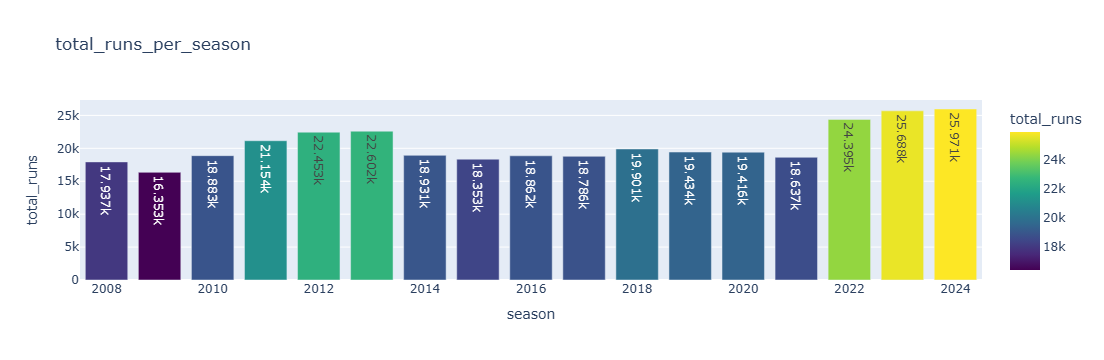

In [246]:
import plotly.express as px

fig=px.bar(
    season_stats,
    x=season_stats.index,
    y='total_runs',
    title='total_runs_per_season',
    labels={'total_suns':'count','index':'season'},
    color='total_runs',
    color_continuous_scale='viridis',
    text_auto=True

)
fig.show()

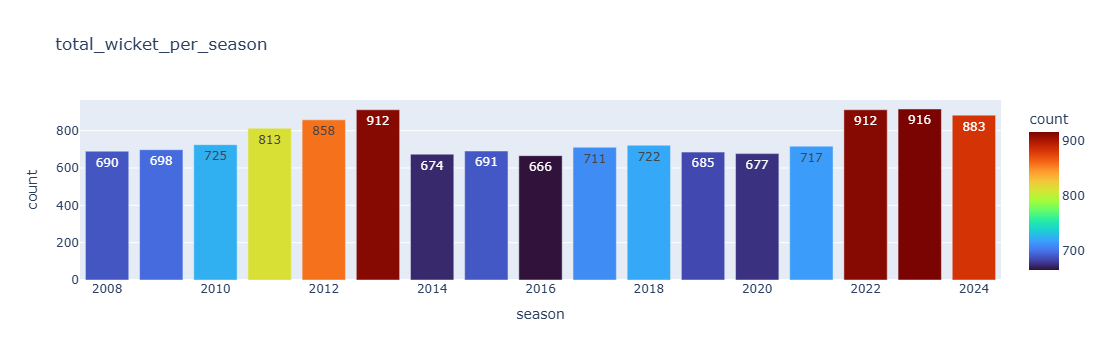

In [55]:
fig=px.bar(
    season_stats,
    x=season_stats.index,
    y='is_wicket',
    title='total_wicket_per_season',
    labels={'is_wicket':'count','index':'season'},
    color='is_wicket',
    color_continuous_scale='turbo',
    text_auto=True

)
fig.show()

          dismissal_kind  count
0                 caught   8063
1                 bowled   2212
2                run out   1114
3                    lbw    800
4      caught and bowled    367
5                stumped    358
6           retired hurt     15
7             hit wicket     15
8  obstructing the field      3
9            retired out      3


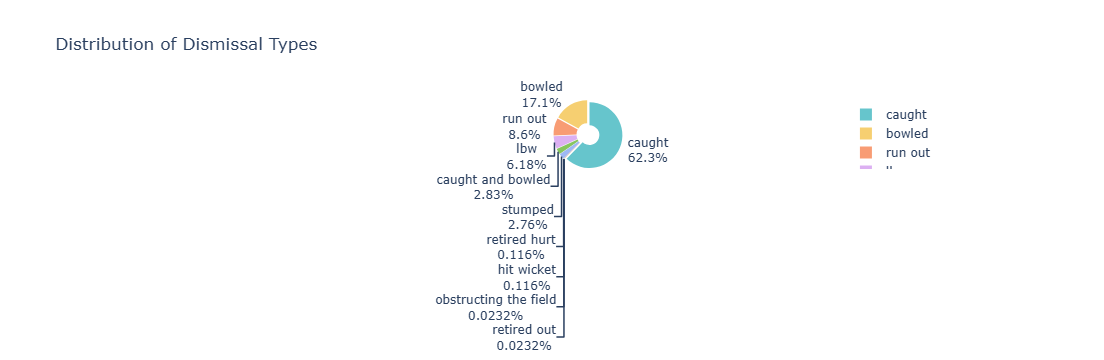

In [56]:
dismissal_counts = df["dismissal_kind"].value_counts()[1:].reset_index()
print(dismissal_counts)
dismissal_counts.columns = ["Dismissal Type", "Count"]

fig = px.pie(
    dismissal_counts,
    names="Dismissal Type",
    values="Count",
    title="Distribution of Dismissal Types",
    color_discrete_sequence=px.colors.qualitative.Pastel,
    hole=0.3,
)

fig.update_traces(textinfo="percent+label", pull=[0.05] * len(dismissal_counts))
fig.show()


In [57]:
matches_team1 = df.groupby(['season','team1'])['match_id'].nunique().reset_index()
matches_team1.rename(columns={'team1':'team','match_id':'matches_played'},inplace=True)

matches_team2 = df.groupby(['season','team2'])['match_id'].nunique().reset_index()
matches_team2.rename(columns={'team2':'team','match_id':'matches_played'},inplace=True)

match_played = pd.concat([matches_team1,matches_team2]).sort_values(by=['season','team'])

matches_played = match_played.groupby(['season','team'])['matches_played'].sum().reset_index()
matches_played

,season,team,matches_played
0,2008,Chennai Super Kings,16
1,2008,Deccan Chargers,14
2,2008,Delhi Daredevils,14
3,2008,Kings XI Punjab,15
4,2008,Kolkata Knight Riders,13
...,...,...,...
141,2024,Mumbai Indians,14
142,2024,Punjab Kings,14
143,2024,Rajasthan Royals,15
144,2024,Royal Challengers Bengaluru,15


In [58]:
matches_won=df.groupby(['season','winner'])['id'].nunique().reset_index()
matches_won.rename(columns={'winner':'team','id':'winnings'},inplace=True)
matches_won

,season,team,winnings
0,2008,Chennai Super Kings,9
1,2008,Deccan Chargers,2
2,2008,Delhi Daredevils,7
3,2008,Kings XI Punjab,10
4,2008,Kolkata Knight Riders,6
...,...,...,...
145,2024,Mumbai Indians,4
146,2024,Punjab Kings,5
147,2024,Rajasthan Royals,9
148,2024,Royal Challengers Bengaluru,7


In [59]:
winning_df=pd.merge(matches_played,matches_won, on=['season','team'], how='left')
winning_df

,season,team,matches_played,winnings
0,2008,Chennai Super Kings,16,9
1,2008,Deccan Chargers,14,2
2,2008,Delhi Daredevils,14,7
3,2008,Kings XI Punjab,15,10
4,2008,Kolkata Knight Riders,13,6
...,...,...,...,...
141,2024,Mumbai Indians,14,4
142,2024,Punjab Kings,14,5
143,2024,Rajasthan Royals,15,9
144,2024,Royal Challengers Bengaluru,15,7


In [60]:
winning_df["win_percentage"] = (
    winning_df["winnings"] / winning_df["matches_played"] * 100
).round(1)
winning_df

,season,team,matches_played,winnings,win_percentage
0,2008,Chennai Super Kings,16,9,56.2
1,2008,Deccan Chargers,14,2,14.3
2,2008,Delhi Daredevils,14,7,50.0
3,2008,Kings XI Punjab,15,10,66.7
4,2008,Kolkata Knight Riders,13,6,46.2
...,...,...,...,...,...
141,2024,Mumbai Indians,14,4,28.6
142,2024,Punjab Kings,14,5,35.7
143,2024,Rajasthan Royals,15,9,60.0
144,2024,Royal Challengers Bengaluru,15,7,46.7


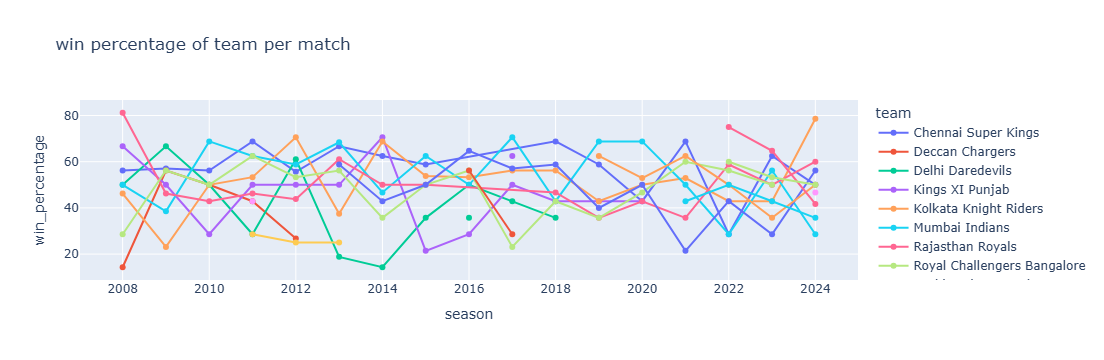

In [61]:
fig=px.line(
    winning_df,
    x='season',
    y='win_percentage',
    color='team',
    markers=True,
    title='win percentage of team per match'
)
fig.show()

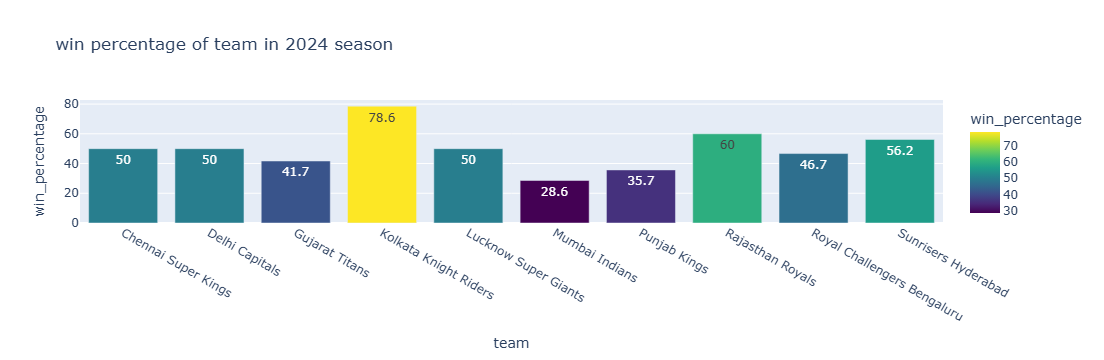

In [62]:
latest_season=winning_df['season'].max()
df_latest=winning_df[winning_df['season']==latest_season]

fig=px.bar(
    df_latest,
    x='team',
    y='win_percentage',
    text='win_percentage',
    title=f'win percentage of team in {latest_season} season',
    color='win_percentage',
    color_continuous_scale='viridis',

)
fig.show()

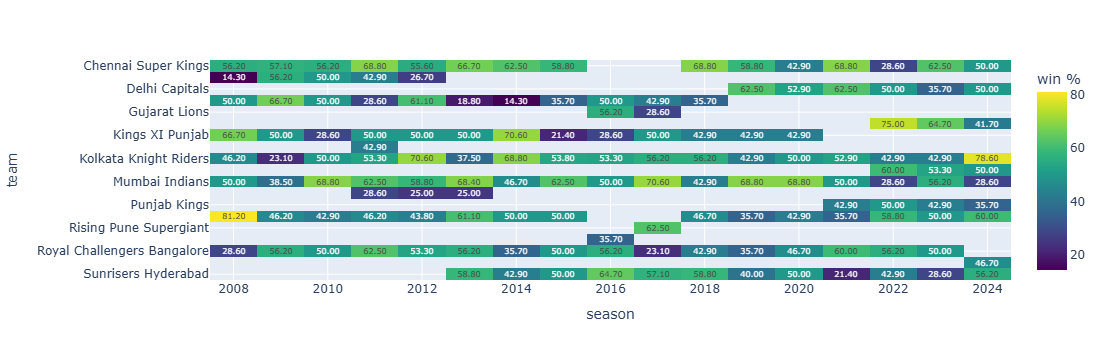

In [63]:
df_pivot=winning_df.pivot(index='team',columns='season',values='win_percentage')

fig=px.imshow(
    df_pivot,
    aspect='auto',
    labels=dict(x='season',y='team',color='win %'),
   color_continuous_scale='viridis',
   text_auto='.2f'
)
fig.show()

In [64]:
best_season = winning_df.loc[winning_df.groupby('team')['win_percentage'].idxmax()]
best_season.sort_values(by='win_percentage', ascending=False).head(5)

,season,team,matches_played,winnings,win_percentage
6,2008,Rajasthan Royals,16,13,81.2
139,2024,Kolkata Knight Riders,14,11,78.6
118,2022,Gujarat Titans,16,12,75.0
80,2017,Mumbai Indians,17,12,70.6
54,2014,Kings XI Punjab,17,12,70.6


In [65]:
top_5_teams=best_season.sort_values(by='win_percentage', ascending=False).head(5)
top_5_teams=top_5_teams.assign(
    season_team=lambda x: x['season'].astype(str) + " - " + x['team']
)
top_5_teams


,season,team,matches_played,winnings,win_percentage,season_team
6,2008,Rajasthan Royals,16,13,81.2,2008 - Rajasthan Royals
139,2024,Kolkata Knight Riders,14,11,78.6,2024 - Kolkata Knight Riders
118,2022,Gujarat Titans,16,12,75.0,2022 - Gujarat Titans
80,2017,Mumbai Indians,17,12,70.6,2017 - Mumbai Indians
54,2014,Kings XI Punjab,17,12,70.6,2014 - Kings XI Punjab


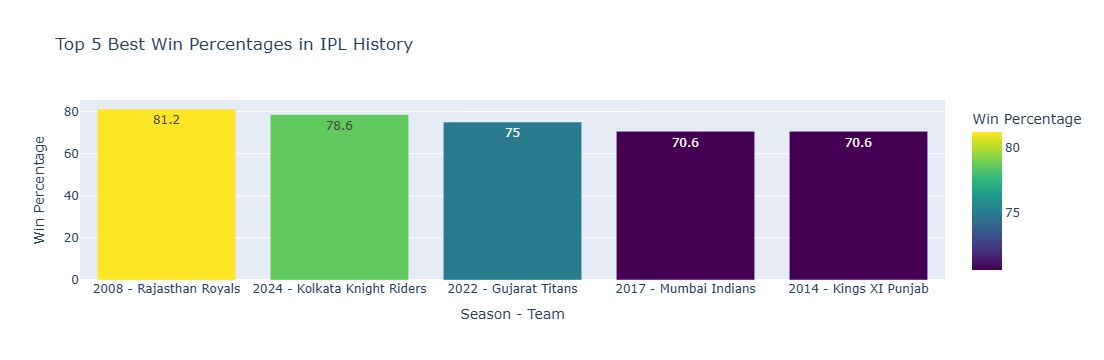

In [66]:
fig = px.bar(
    top_5_teams,
    x="season_team",
    y="win_percentage",
    text="win_percentage",
    labels={"win_percentage": "Win Percentage", "season_team": "Season - Team"},
    title="Top 5 Best Win Percentages in IPL History",
    color="win_percentage",
    color_continuous_scale="viridis",
)

fig.show()

In [67]:
team_wins=winning_df.groupby(['team'])['winnings'].sum().sort_values(ascending=False)
team_wins

team
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: winnings, dtype: int64

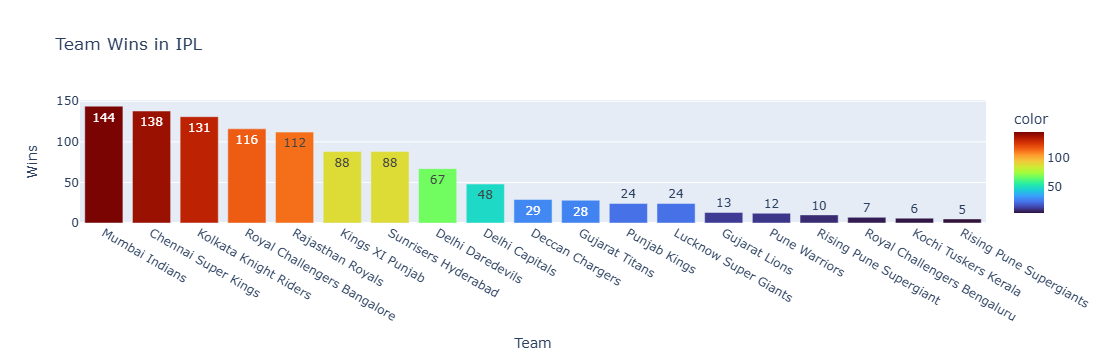

In [68]:
fig = px.bar(
    x=team_wins.index,
    y=team_wins.values,
    color=team_wins.values,
    labels={"x": "Team", "y": "Wins"},
    title="Team Wins in IPL",
    text=team_wins.values,
    color_continuous_scale="turbo",
)
fig.show()

In [69]:
last_over=(
    df[df['over']>15]
    .groupby(['batter'])['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
last_over.head(5)

,batter,batsman_runs
0,MS Dhoni,2786
1,KA Pollard,1708
2,KD Karthik,1565
3,AB de Villiers,1421
4,RA Jadeja,1420


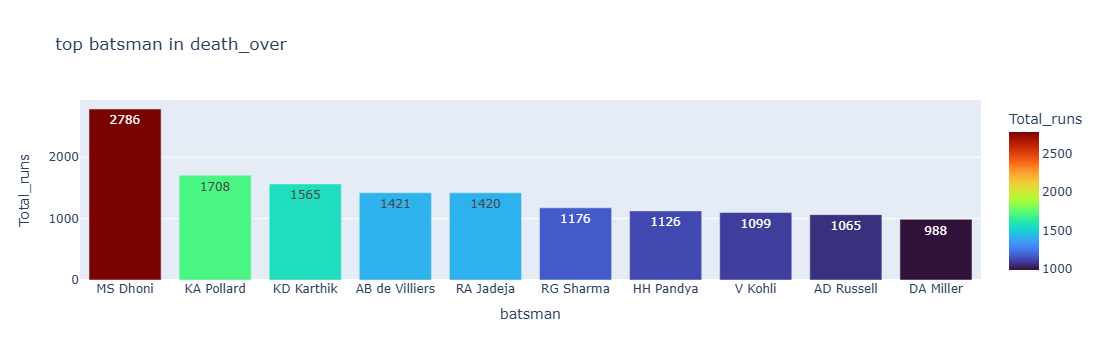

In [70]:
fig=px.bar(
    last_over.head(10),
    x='batter',
    y='batsman_runs',
    color='batsman_runs',
    text='batsman_runs',
    labels={'batter':'batsman','batsman_runs':'Total_runs'},
    title='top batsman in death_over',
    color_continuous_scale='turbo'
)
fig.show()

In [71]:
df.sample(5).T

,203109,184248,62142,175143,132417
match_id,1254097,1216513,548321,1178418,980983
inning,2,1,1,2,2
batting_team,Rajasthan Royals,Kings XI Punjab,Deccan Chargers,Rajasthan Royals,Delhi Daredevils
bowling_team,Delhi Capitals,Chennai Super Kings,Delhi Daredevils,Kolkata Knight Riders,Sunrisers Hyderabad
over,10,17,5,14,7
ball,4,5,4,6,5
batter,R Parag,GJ Maxwell,PA Patel,S Gopal,Q de Kock
bowler,K Rabada,SN Thakur,AB Agarkar,N Rana,BB Sran
non_striker,SV Samson,SN Khan,S Dhawan,R Parag,KK Nair
batsman_runs,0,0,2,4,6


In [72]:
bat_first_win = df[df["result"] == "runs"]["match_id"].nunique()
chase_win = df[df["result"] == "wickets"]["match_id"].nunique()

win_data = pd.DataFrame(
    {
        "Result": ["Batting First Wins", "Chasing Wins"],
        "Count": [bat_first_win, chase_win],
    }
)
win_data

,Result,Count
0,Batting First Wins,498
1,Chasing Wins,578


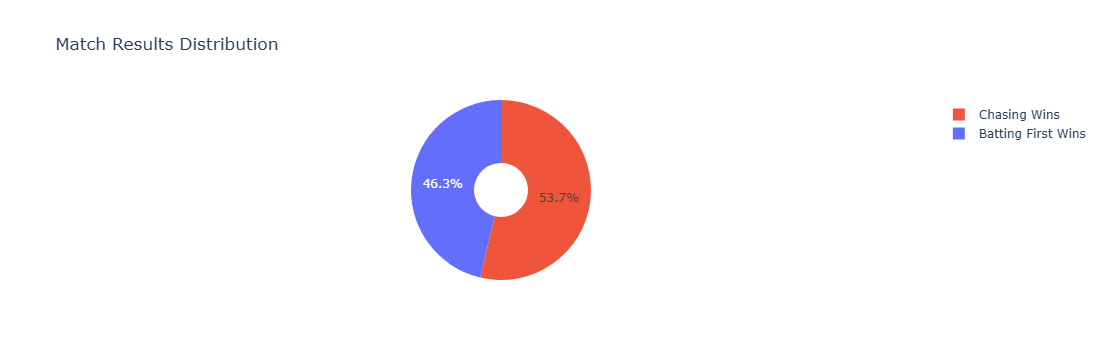

In [73]:
fig = px.pie(
    win_data,
    names="Result",
    values="Count",
    title="Match Results Distribution",
    color="Result",
    hole=0.3,
)
fig.show()

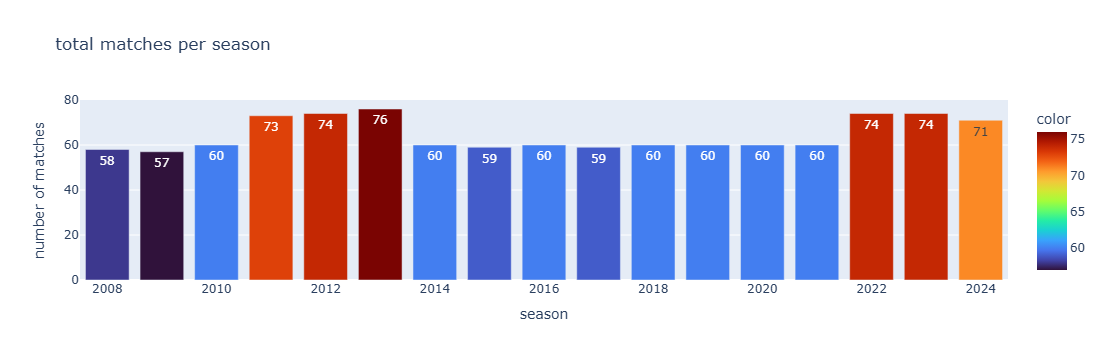

In [74]:
fig=px.bar(
    x=df.groupby('season')['match_id'].nunique().index,
    y=df.groupby('season')['match_id'].nunique().values,
    color=df.groupby('season')['match_id'].nunique().values,
    title='total matches per season',
    text=df.groupby('season')['match_id'].nunique().values,
    color_continuous_scale='turbo',
    labels={'x':'season','y':'number of matches'}
)
fig.show()

In [75]:
df[df['batsman_runs']==6].head(5)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,method,umpire1,umpire2,is_legal,legal_ball,all_balls_over_ball,adjusted_over_ball,match_number_of_that_season,matches_in_that_season,match_number_in_total
10,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,4,BB McCullum,Z Khan,SC Ganguly,6,...,normal,Asad Rauf,RE Koertzen,True,4,1.4,1.4,1,58,1
20,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,3,2,BB McCullum,AA Noffke,SC Ganguly,6,...,normal,Asad Rauf,RE Koertzen,True,1,3.2,3.1,1,58,1
25,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,3,7,BB McCullum,AA Noffke,SC Ganguly,6,...,normal,Asad Rauf,RE Koertzen,True,6,3.7,3.6,1,58,1
60,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,9,5,BB McCullum,SB Joshi,RT Ponting,6,...,normal,Asad Rauf,RE Koertzen,True,5,9.5,9.5,1,58,1
65,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,10,4,RT Ponting,JH Kallis,BB McCullum,6,...,normal,Asad Rauf,RE Koertzen,True,4,10.4,10.4,1,58,1


<Axes: xlabel='batting_team'>

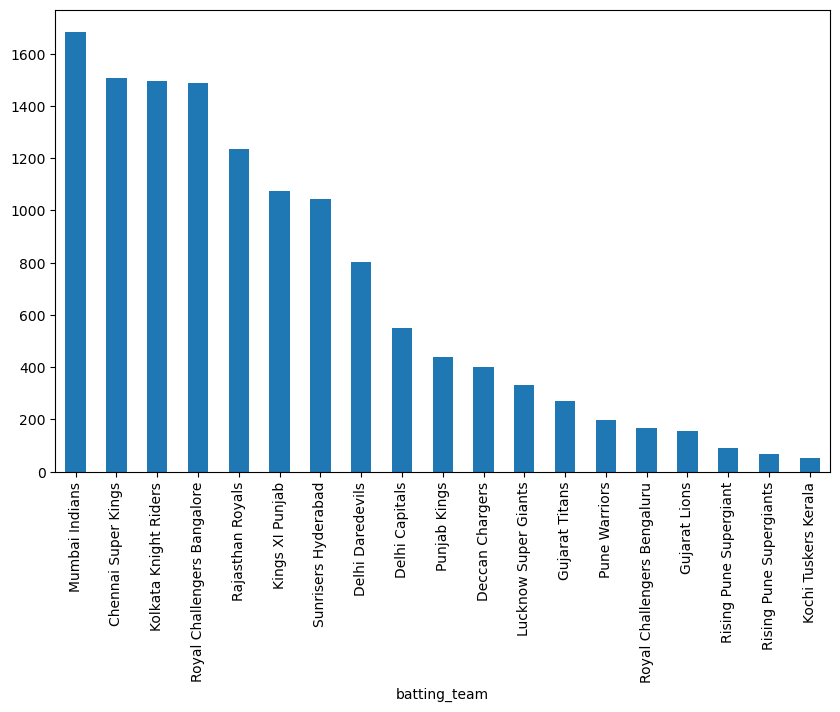

In [76]:
df[df['batsman_runs']==6].groupby('batting_team')['batsman_runs'].count().sort_values(ascending=False).plot(kind='bar',figsize=(10,6))



<Axes: xlabel='batting_team'>

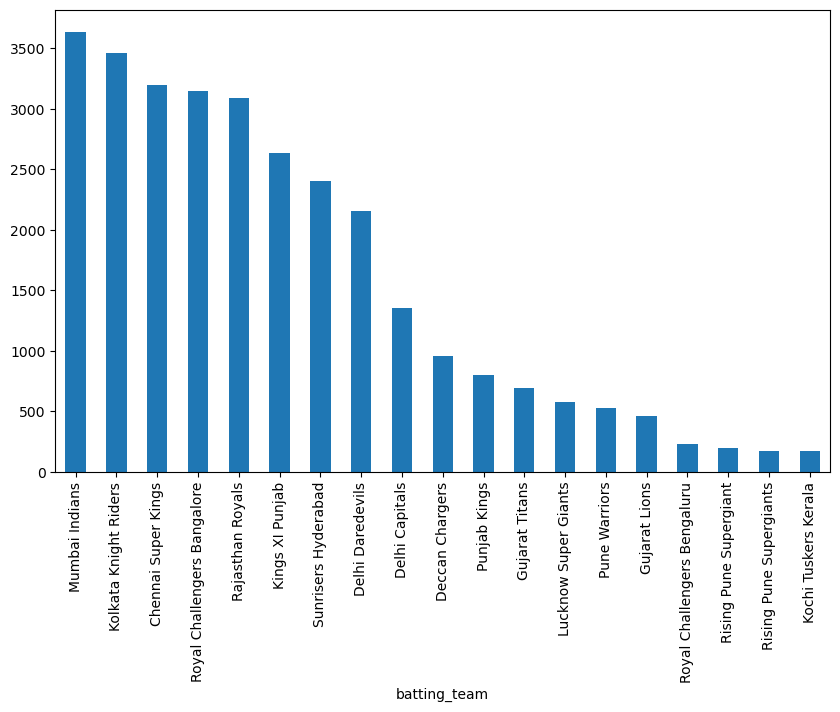

In [77]:
df[df['batsman_runs']==4].groupby('batting_team')['batsman_runs'].count().sort_values(ascending=False).plot(kind='bar',figsize=(10,6))

<Axes: xlabel='batter'>

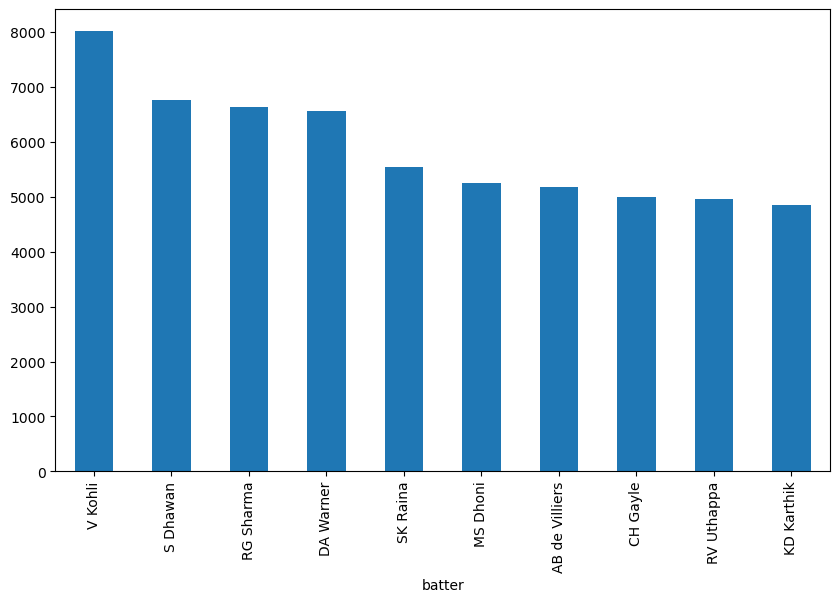

In [78]:
df.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10).plot(kind='bar',figsize=(10,6))

In [79]:
df['extras_type'].unique()

array(['legbyes', 'none', 'wides', 'byes', 'noballs', 'penalty'],
      dtype=object)

In [80]:
batting_stats = (
    df.query("extras_type.isin(['none'])")
    .groupby(["batter"])
    .agg(
        runs=("batsman_runs", "sum"),
        total_balls=("is_legal", "count"),
        total_matches=("match_id", "count"),
    )
    .reset_index()
    .assign(
        strike_rate=lambda x: (x["runs"] / x["total_balls"] * 100).round(2),
    )
)
batting_stats.sort_values("strike_rate", ascending=False).head(10)

,batter,runs,total_balls,total_matches,strike_rate
312,L Wood,9,3,3,300.00
461,R Sai Kishore,13,5,5,260.00
293,KMDN Kulasekara,5,2,2,250.00
97,B Stanlake,5,2,2,250.00
234,J Fraser-McGurk,324,136,136,238.24
629,Umar Gul,39,17,17,229.41
478,RJ Gleeson,2,1,1,200.00
640,VRV Singh,4,2,2,200.00
497,RS Sodhi,4,2,2,200.00
465,R Shepherd,115,60,60,191.67


<Axes: xlabel='batter'>

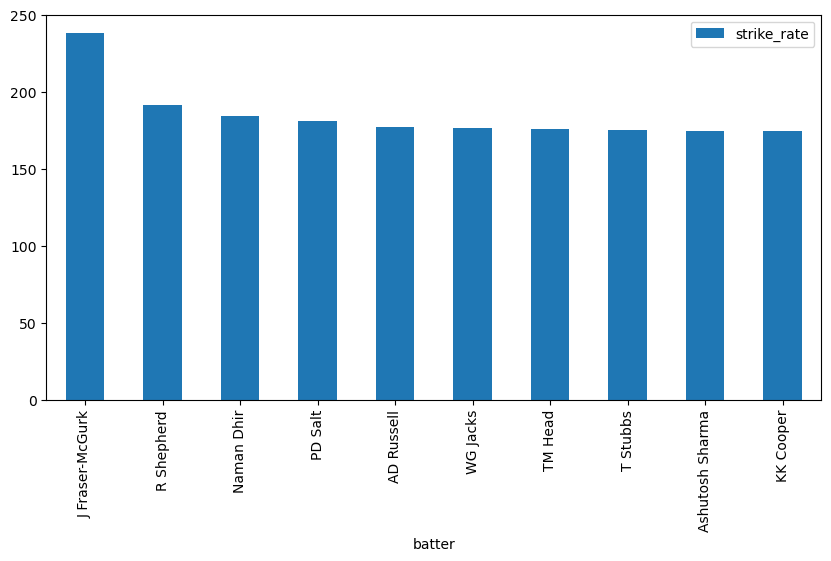

In [81]:
batting_stats.query('total_matches >=60').sort_values(
    by='strike_rate', ascending=False
).head(10).plot(kind='bar',x='batter',y='strike_rate',figsize=(10,5))

In [82]:
df.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).reset_index(name='wickets').head(10)

,bowler,wickets
0,YS Chahal,213
1,DJ Bravo,207
2,PP Chawla,201
3,SP Narine,200
4,R Ashwin,198
5,B Kumar,195
6,SL Malinga,188
7,A Mishra,183
8,JJ Bumrah,182
9,RA Jadeja,169


In [83]:
bowler_stats = (
    df.groupby("bowler")
    .agg({"total_runs": "sum", "adjusted_over_ball": "count", "match_id": "nunique"})
    .sort_values(by="total_runs", ascending=False)
    .rename(columns={"match_id": "matches"})
    .reset_index()
)
bowler_stats = bowler_stats.assign(
    economy=lambda x: (x["total_runs"] / (x["adjusted_over_ball"] / 6)).round(2)
)
bowler_stats

,bowler,total_runs,adjusted_over_ball,matches,economy
0,R Ashwin,5435,4679,208,6.97
1,PP Chawla,5179,3895,191,7.98
2,B Kumar,5051,4060,176,7.46
3,RA Jadeja,4917,3895,211,7.57
4,YS Chahal,4681,3628,159,7.74
...,...,...,...,...,...
525,AM Rahane,5,6,1,5.00
526,SPD Smith,5,2,1,15.00
527,Atharva Taide,4,1,1,24.00
528,DA Warner,2,2,1,6.00


<Axes: xlabel='bowler'>

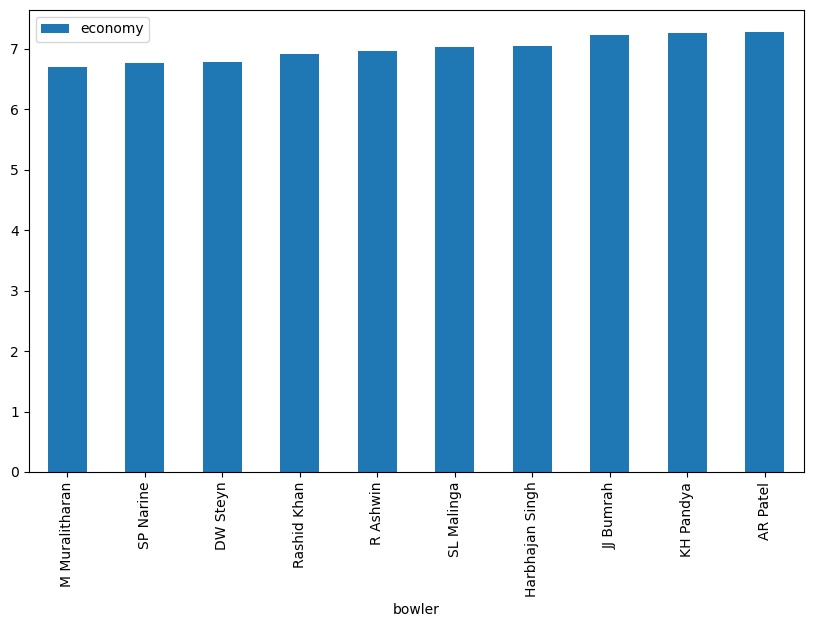

In [84]:
bowler_stats.query('matches>=60').sort_values('economy',ascending=True).head(10).plot(kind='bar',x='bowler',y='economy',figsize=(10,6))


In [85]:
toss_win_match_win=df.groupby('match_id').first().groupby(['toss_winner','winner']).size().unstack().fillna(0).astype(int)
toss_win_match_win

winner,Chennai Super Kings,Deccan Chargers,Delhi Capitals,Delhi Daredevils,Gujarat Lions,Gujarat Titans,Kings XI Punjab,Kochi Tuskers Kerala,Kolkata Knight Riders,Lucknow Super Giants,Mumbai Indians,Pune Warriors,Punjab Kings,Rajasthan Royals,Rising Pune Supergiant,Rising Pune Supergiants,Royal Challengers Bangalore,Royal Challengers Bengaluru,Sunrisers Hyderabad,no result
toss_winner,,,,,,,,,,,,,,,,,,,,
Chennai Super Kings,75,1,2,4,0,2,5,0,5,0,7,1,3,7,0,0,6,1,2,1
Deccan Chargers,2,19,0,5,0,0,3,0,3,0,4,1,0,3,0,0,3,0,0,0
Delhi Capitals,3,0,26,0,0,1,2,0,2,1,4,0,1,3,0,0,3,1,3,0
Delhi Daredevils,5,0,0,35,1,0,7,0,5,0,9,1,0,7,0,0,5,0,4,1
Gujarat Lions,0,0,0,0,10,0,2,0,0,0,1,0,0,0,0,0,2,0,0,0
Gujarat Titans,2,0,1,0,0,14,0,0,1,0,2,0,1,0,0,0,1,0,0,0
Kings XI Punjab,4,2,1,3,0,0,36,0,8,0,7,2,0,6,0,1,7,0,8,0
Kochi Tuskers Kerala,0,1,0,0,0,0,0,4,0,0,0,1,0,0,0,0,2,0,0,0
Kolkata Knight Riders,10,1,2,5,0,0,6,2,68,2,10,1,1,5,0,0,3,0,6,0


<Axes: xlabel='winner', ylabel='toss_winner'>

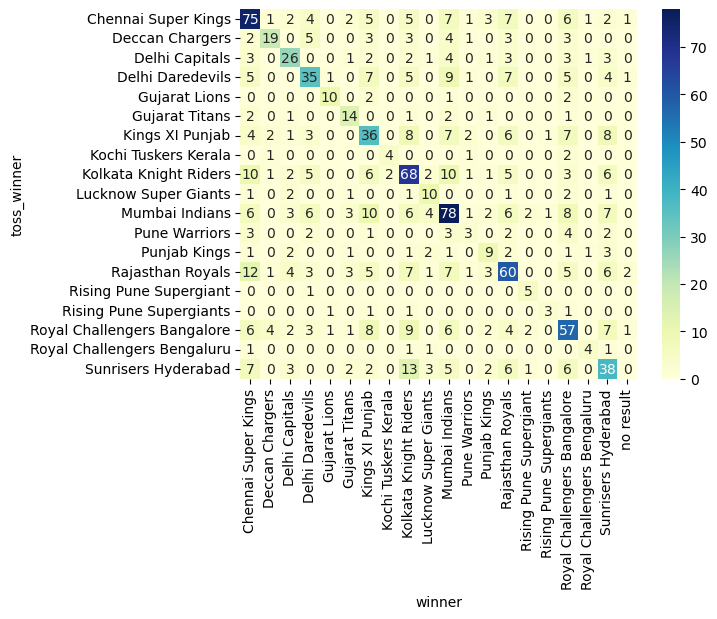

In [86]:
sns.heatmap(toss_win_match_win, annot=True, cmap="YlGnBu",fmt='d')

(19, 2)
                         winner         result type  wins
0           Chennai Super Kings  batting First wins    71
1               Deccan Chargers  batting First wins    18
2                Delhi Capitals  batting First wins    21
3              Delhi Daredevils  batting First wins    25
4                 Gujarat Lions  batting First wins     1
5                Gujarat Titans  batting First wins    11
6               Kings XI Punjab  batting First wins    40
7          Kochi Tuskers Kerala  batting First wins     2
8         Kolkata Knight Riders  batting First wins    54
9          Lucknow Super Giants  batting First wins    16
10               Mumbai Indians  batting First wins    71
11                Pune Warriors  batting First wins     6
12                 Punjab Kings  batting First wins    11
13             Rajasthan Royals  batting First wins    43
14       Rising Pune Supergiant  batting First wins     5
15      Rising Pune Supergiants  batting First wins     2
16  Ro

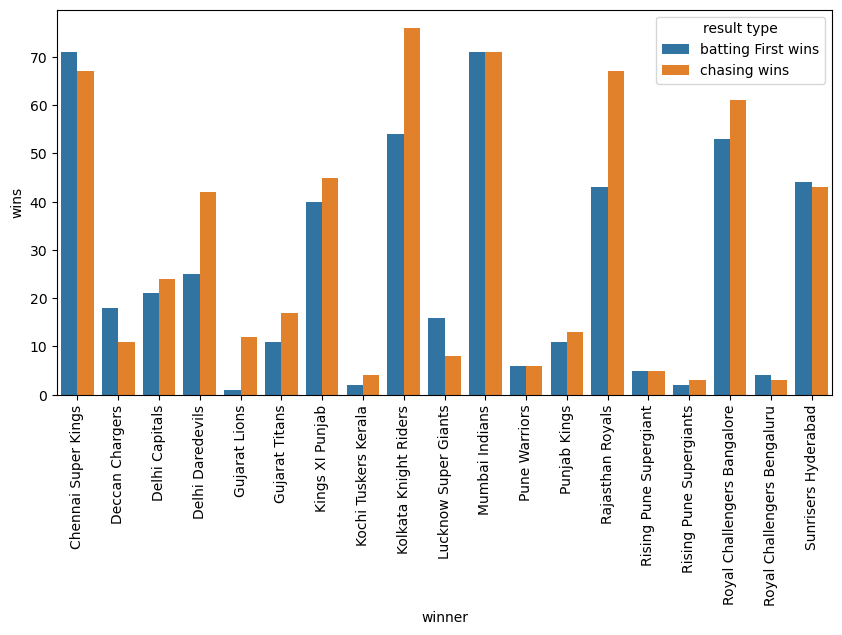

In [87]:
bat_first_win=matches[matches['result']=='runs'].groupby('winner').size()
chase_win=matches[matches['result']=='wickets'].groupby('winner').size()

bat_vs_chase=pd.DataFrame({'batting First wins':bat_first_win,'chasing wins':chase_win}).fillna(0)
print(bat_vs_chase.shape)


bat_vs_chase=bat_vs_chase.reset_index().melt(id_vars='winner',var_name='result type',value_name='wins')
print(bat_vs_chase.head(20))
plt.figure(figsize=(10,5))
sns.barplot(data=bat_vs_chase,x='winner',y='wins',hue='result type')
plt.xticks(rotation=90)
plt.show()

In [88]:
df[df['is_wicket']==1].head(5)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,method,umpire1,umpire2,is_legal,legal_ball,all_balls_over_ball,adjusted_over_ball,match_number_of_that_season,matches_in_that_season,match_number_in_total
33,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,5,2,SC Ganguly,Z Khan,BB McCullum,0,...,normal,Asad Rauf,RE Koertzen,True,2,5.2,5.2,1,58,1
74,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,12,1,RT Ponting,JH Kallis,BB McCullum,0,...,normal,Asad Rauf,RE Koertzen,True,1,12.1,12.1,1,58,1
106,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,17,1,DJ Hussey,AA Noffke,BB McCullum,0,...,normal,Asad Rauf,RE Koertzen,True,1,17.1,17.1,1,58,1
131,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,1,1,R Dravid,I Sharma,W Jaffer,0,...,normal,Asad Rauf,RE Koertzen,True,1,1.1,1.1,1,58,1
138,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,2,2,V Kohli,AB Dinda,W Jaffer,0,...,normal,Asad Rauf,RE Koertzen,True,2,2.2,2.2,1,58,1


C:\Users\Vishal\AppData\Local\Temp\ipykernel_7220\153352316.py:2: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




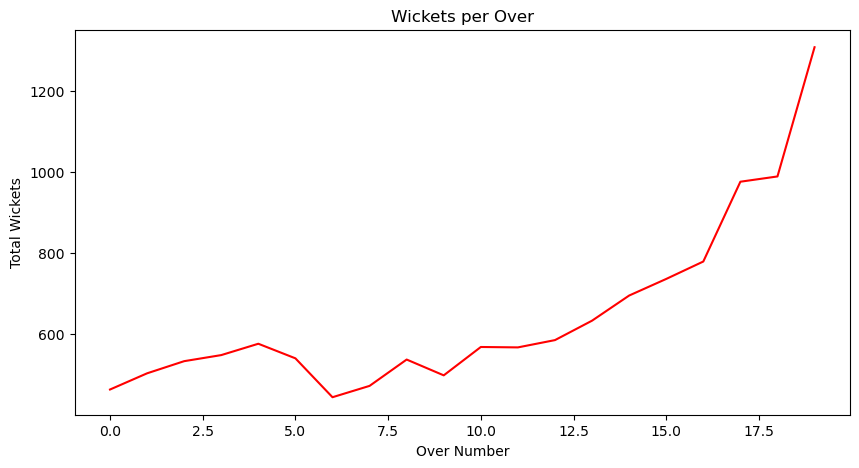

In [89]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df[df["is_wicket"] == 1],
    x="over",
    y="is_wicket",
    estimator="sum",
    ci=None,
    color="red",
)
plt.title("Wickets per Over")
plt.xlabel("Over Number")
plt.ylabel("Total Wickets")
plt.show()

In [90]:
df.groupby(['match_id']).first().loc[:,'match_type'].value_counts()

match_type
League                1029
Final                   17
Qualifier 1             14
Qualifier 2             14
Eliminator              11
Semi Final               6
Elimination Final        3
3rd Place Play-Off       1
Name: count, dtype: int64

In [91]:
df.sample(3)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,method,umpire1,umpire2,is_legal,legal_ball,all_balls_over_ball,adjusted_over_ball,match_number_of_that_season,matches_in_that_season,match_number_in_total
36259,419143,2,Rajasthan Royals,Kings XI Punjab,3,2,MJ Lumb,J Theron,NV Ojha,1,...,normal,S Ravi,SK Tarapore,True,2,3.2,3.2,38,60,153
71383,548361,1,Rajasthan Royals,Chennai Super Kings,14,6,BJ Hodge,DJ Bravo,J Botha,2,...,normal,BNJ Oxenford,C Shamshuddin,True,5,14.6,14.5,54,74,302
119921,829799,2,Kings XI Punjab,Sunrisers Hyderabad,10,4,DA Miller,MC Henriques,GJ Bailey,1,...,normal,AK Chaudhary,HDPK Dharmasena,True,4,10.4,10.4,47,59,505


In [92]:
total_runs=df.groupby(['match_id','inning'])['total_runs'].sum().reset_index()
total_runs

,match_id,inning,total_runs
0,335982,1,222
1,335982,2,82
2,335983,1,240
3,335983,2,207
4,335984,1,129
...,...,...,...
2212,1426310,2,174
2213,1426311,1,175
2214,1426311,2,139
2215,1426312,1,113


In [93]:
total_runs=(
    df.groupby(['match_id','inning'])['total_runs'].sum().reset_index()
    .pivot_table(
        values='total_runs',
        index='match_id',
        columns='inning',
    ).reset_index()
    .rename(columns={1:'team_1_runs',2:'team_2_runs'})
    .drop(columns=[3,4,5,6], errors='ignore')
)
total_runs

inning,match_id,team_1_runs,team_2_runs
0,335982,222.0,82.0
1,335983,240.0,207.0
2,335984,129.0,132.0
3,335985,165.0,166.0
4,335986,110.0,112.0
...,...,...,...
1090,1426307,214.0,215.0
1091,1426309,159.0,164.0
1092,1426310,172.0,174.0
1093,1426311,175.0,139.0


In [94]:
df=df.merge(total_runs,left_on='match_id',right_on='match_id',how='left')
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,umpire2,is_legal,legal_ball,all_balls_over_ball,adjusted_over_ball,match_number_of_that_season,matches_in_that_season,match_number_in_total,team_1_runs,team_2_runs
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,RE Koertzen,True,1,0.1,0.1,1,58,1,222.0,82.0
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,RE Koertzen,True,2,0.2,0.2,1,58,1,222.0,82.0
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,RE Koertzen,False,2,0.3,0.2,1,58,1,222.0,82.0
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,RE Koertzen,True,3,0.4,0.3,1,58,1,222.0,82.0
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,RE Koertzen,True,4,0.5,0.4,1,58,1,222.0,82.0


In [95]:
df.isna().sum().sort_values(ascending=False)[ :2]

team_2_runs    309
method           0
dtype: int64

In [96]:
x=df[df['team_2_runs'].isna()]['match_id'].drop_duplicates()
x

57068      501265
115599     829763
236750    1359519
Name: match_id, dtype: int64

In [97]:
df[df['match_id'].isin(x)][['match_id','team1','team2','result','winner','date']].drop_duplicates()

,match_id,team1,team2,result,winner,date
57068,501265,Delhi Daredevils,Pune Warriors,no result,no result,2011-05-21
115599,829763,Royal Challengers Bangalore,Rajasthan Royals,no result,no result,2015-04-29
236750,1359519,Lucknow Super Giants,Chennai Super Kings,no result,no result,2023-05-03


In [98]:
df['team_2_runs'].fillna(0,inplace=True)

C:\Users\Vishal\AppData\Local\Temp\ipykernel_7220\344988823.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [99]:
df.isna().sum().sum()

0

In [100]:
df=df.assign(
    total_match_runs=lambda x: x['team_1_runs']+ x['team_2_runs'],
    is_league_match=lambda x: x['match_type']=='League'
)

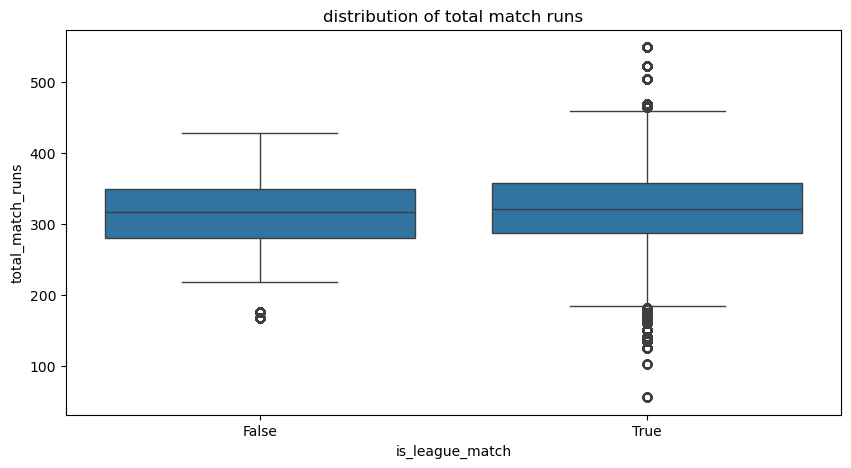

In [101]:
plt.figure(figsize=(10,5))
sns.boxplot(df,x='is_league_match', y='total_match_runs')
plt.title('distribution of total match runs')
plt.show()

In [102]:
df.to_csv('final.csv',index=False)

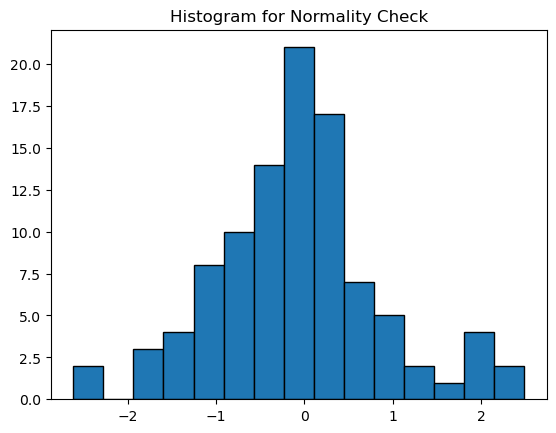

In [103]:
import matplotlib.pyplot as plt
import numpy as np

data = np.random.normal(loc=0, scale=1, size=100)  # Normal data
plt.hist(data, bins=15, edgecolor='black')
plt.title("Histogram for Normality Check")
plt.show()

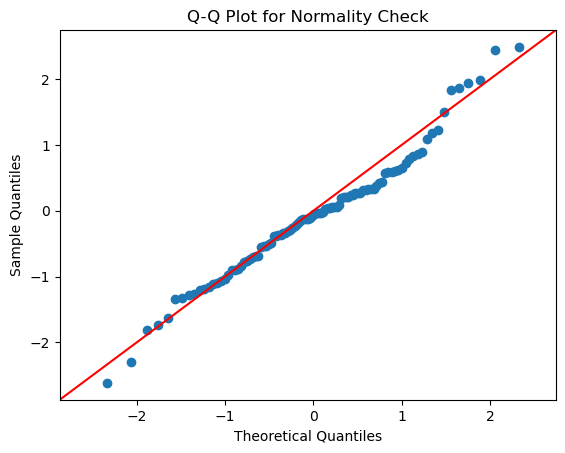

In [104]:
import statsmodels.api as sm
import scipy.stats as stats

sm.qqplot(data, line='45')
plt.title("Q-Q Plot for Normality Check")
plt.show()

In [105]:
from scipy.stats import shapiro

stat, p = shapiro(data)
print(f"Shapiro-Wilk Test: p-value = {p:.4f}")
if p > 0.05:
    print("Data is normally distributed (fail to reject H₀)")
else:
    print("Data is NOT normally distributed (reject H₀)")

Shapiro-Wilk Test: p-value = 0.1226
Data is normally distributed (fail to reject H₀)


In [106]:
from scipy.stats import kstest

stat, p = kstest(data, 'norm')  # Compare to normal dist
print(f"KS Test p-value = {p:.4f}")

KS Test p-value = 0.0675


In [107]:
from scipy.stats import anderson
# You need to run the Anderson-Darling test separately for each dataset
result1 = anderson(df[df['is_league_match']==True]['total_match_runs'])
result2 = anderson(df[df['is_league_match']==False]['total_match_runs'])



In [108]:
print(f'AD statistics:{result1.statistic:4f}')
print('critical Values',result1.critical_values)
print('significance levels',result1.significance_level)
if result1.statistic < result1.critical_values[2]:
    print('normal distribution(fail to reject Ho)')
else:
    print('not normal distribution(reject Ho)')

AD statistics:338.894720
critical Values [0.576 0.656 0.787 0.918 1.092]
significance levels [15.  10.   5.   2.5  1. ]
not normal distribution(reject Ho)


In [109]:
print(f'AD statistics:{result2.statistic:4f}')
print('critical Values',result2.critical_values)
print('significance levels',result2.significance_level)
if result2.statistic < result2.critical_values[2]:
    print('normal distribution(fail to reject Ho)')
else:
    print('not normal distribution(reject Ho)')

AD statistics:51.239492
critical Values [0.576 0.656 0.787 0.918 1.092]
significance levels [15.  10.   5.   2.5  1. ]
not normal distribution(reject Ho)


In [110]:
from scipy.stats import mannwhitneyu
stats, p=mannwhitneyu(
    df[df['is_league_match']==True]['total_match_runs'],
    df[df['is_league_match']==False]['total_match_runs']
)
print(f'mannwhitneyu test stats={stats},p={p:.4f}')

mannwhitneyu test stats=2027927718.5,p=0.0000


In [111]:
from base64 import encode
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

label_cols=(
    'batting_team',
    'bowling_team',
    'toss_winner',
    'winner',
    'venue',
    'season'
)
encoder=LabelEncoder()

for col in label_cols:
  df[col]=encoder.fit_transform(df[col])

In [112]:
df['toss_win']=(df['toss_winner']==df['batting_team']).astype(int)
features=df[['batting_team','bowling_team','toss_win','venue','season']]
target=df['winner']

In [113]:
x_train,x_test,y_train,y_test=train_test_split(features,target,test_size=0.2,random_state=42,stratify=target)

In [114]:
model=RandomForestClassifier(n_estimators=200,max_depth=10,min_samples_split=5,random_state=42)
model.fit(x_train,y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=200,
                       random_state=42)

In [115]:
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f'match winner prediction accuracy:{accuracy*100:.2f}%')
print(classification_report(y_test,y_pred))

match winner prediction accuracy:80.77%
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      6678
           1       1.00      0.33      0.50      1402
           2       0.88      1.00      0.94      2328
           3       0.67      0.59      0.63      3142
           4       1.00      0.18      0.31       612
           5       0.84      0.99      0.91      1359
           6       0.68      0.59      0.63      4190
           7       1.00      0.14      0.24       264
           8       0.78      0.84      0.81      6164
           9       0.91      0.85      0.88      1186
          10       0.79      0.79      0.79      6926
          11       1.00      0.16      0.28       576
          12       1.00      0.53      0.69      1168
          13       0.83      0.89      0.86      5406
          14       1.00      0.25      0.40       477
          15       1.00      0.23      0.37       221
          16       0.69      0.97      0.

In [116]:
cv_score=cross_val_score(model,x_train,y_train,cv=5,scoring='accuracy')
print(f'cross validation score accuracy:{np.mean(cv_score)*100:2f}%')

cross validation score accuracy:81.265807%


In [117]:
importance=pd.Series(model.feature_importances_,index=x_train.columns).sort_values(ascending=False)
print(f'feature importance:\n',importance)

feature importance:
 bowling_team    0.325694
batting_team    0.299233
venue           0.187006
season          0.160319
toss_win        0.027748
dtype: float64


In [118]:
a=pd.read_csv('final_csv')
null_percentage(a)

C:\Users\Vishal\AppData\Local\Temp\ipykernel_7220\346148907.py:1: DtypeWarning:

Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.



Null percentage for all columns:
 match_id                       0.0
inning                         0.0
batting_team                   0.0
bowling_team                   0.0
over                           0.0
ball                           0.0
batter                         0.0
bowler                         0.0
non_striker                    0.0
batsman_runs                   0.0
extra_runs                     0.0
total_runs                     0.0
extras_type                    0.0
is_wicket                      0.0
player_dismissed               0.0
dismissal_kind                 0.0
fielder                        0.0
id                             0.0
season                         0.0
city                           0.0
date                           0.0
match_type                     0.0
player_of_match                0.0
venue                          0.0
team1                          0.0
team2                          0.0
toss_winner                    0.0
toss_decision        

Series([], dtype: object)